# MECE - Group 2
## Team Tasks

| Individual Responsible | Task | Status | Results | Notes |
|------------------------|------|--------|---------|-------|
|**Data Preprocessing**|
| Clifford Addison | Regex Used? </br> Emoji Handling Done? </br> Slang Handling Done? </br> Abbreviations Handled? </br> Negation Handled </br> Class Separability Checked? </br> Train and Test Handled Correctly? | <div align="center"> Yes<br>Done<br>Done<br>Done<br>Done<br>Done<br>Done </div> | regex patterns used </br> All emojis handled via demojize </br> 50+ slangs handled </br> 78+ abbreviations handled </br> Contractions used to expand words like "wasn't" to 'was not' and "don't" to 'do not' </br> TF-IDF + PCA showed best separability </br> Stratified 80/20 split for all models ||

In [1]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import emoji
import unicodedata
import nltk
import spacy
from spacy import displacy
import warnings
warnings.filterwarnings('ignore')

# NLP Libraries
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Emoji handling
import emoji

# Spell correction and contractions
from textblob import TextBlob
import contractions
from langdetect import detect, LangDetectException

# Multiprocessing and progress bars
from multiprocessing import Pool, cpu_count
from functools import lru_cache, partial
from tqdm import tqdm

# ML and encoding
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# Deep learning tools
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Word embeddings
from gensim.models import Word2Vec

In [2]:
# Setup NLP resources
import nltk
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
spacy_nlp = spacy.load("en_core_web_sm")
lemmatizer = WordNetLemmatizer()

In [3]:
# Load spaCy model for NER
import en_core_web_sm
nlp_spacy = en_core_web_sm.load()

# Disable unnecessary components for faster NER
nlp_spacy.disable_pipes("tagger", "parser", "lemmatizer")

['tagger', 'parser', 'lemmatizer']

In [4]:
# Load Data
corpus_df = pd.read_csv("/content/Sentiment_Data.csv", encoding="ISO-8859-1")

In [5]:
# Check the head of the dataframe
corpus_df.head()

,Tweet,Sentiment
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos


In [6]:
# Show data overview
print("Dataset Overview:")
print(f"Dataset shape: {corpus_df.shape}")
print(f"Columns: {corpus_df.columns.tolist()}")
print("\nSentiment Distribution:")
print(corpus_df['Sentiment'].value_counts())

Dataset Overview:
Dataset shape: (451332, 2)
Columns: ['Tweet', 'Sentiment']

Sentiment Distribution:
Sentiment
Strong_Pos    233700
Neutral        77016
Mild_Pos       64004
Strong_Neg     42556
Mild_Neg       34056
Name: count, dtype: int64


In [7]:
# Create abbreviation dictionary
slang_dict = {
    "u": "you",
    "ur": "your",
    "n": "and",
    "2": "to",
    "4": "for",
    "w/": "with",
    "w/o": "without",
    "thru": "through",
    "tho": "though",
    "gonna": "going to",
    "wanna": "want to",
    "gotta": "got to",
    "kinda": "kind of",
    "sorta": "sort of",
    "outta": "out of",
    "dunno": "don't know",
    "gimme": "give me",
    "lemme": "let me",
    "btw": "by the way",
    "omg": "oh my god",
    "lol": "laugh out loud",
    "rofl": "rolling on floor laughing",
    "smh": "shaking my head",
    "tbh": "to be honest",
    "imo": "in my opinion",
    "imho": "in my humble opinion",
    "aka": "also known as",
    "asap": "as soon as possible",
    "fyi": "for your information",
    "diy": "do it yourself",
    "faq": "frequently asked questions",
    "irl": "in real life",
    "ppl": "people",
    "msg": "message",
    "txt": "text",
    "pic": "picture",
    "vid": "video",
    "app": "application",
    "tech": "technology",
    "biz": "business",
    "edu": "education",
    "gov": "government",
    "org": "organization",
    "info": "information",
    "omg": "oh my god",
    "lol": "laugh out loud",
    "btw": "by the way",
    "idk": "i do not know",
    "smh": "shaking my head",
    "afaik": "as far as i know",
    "tbh": "to be honest",
    "imo": "in my opinion",
    "icymi": "in case you missed it",
    "fwiw": "for what it is worth",
    "ftw": "for the win",
    "lmk": "let me know",
    "rn": "right now",
    "thx": "thanks",
    "til": "today i learned",
    "brb": "be right back",
    "gg": "good game",
    "noob": "newbie",
    "ootd": "outfit of the day",
    "fyp": "for you page",
    "hmu": "hit me up",
    "iiuc": "if i understand correctly",
    "ikr": "i know, right",
    "irl": "in real life",
    "iss": "i am so sorry",
    "jsyk": "just so you know",
    "lowkey": "quietly",
    "highkey": "obviously",
    "ngl": "not gonna lie",
    "oot": "out of the",
    "pls": "please",
    "rizz": "charisma",
    "ship": "support a romantic relationship",
    "slay": "do something well",
    "s/o": "shoutout",
    "stan": "support",
    "tbf": "to be fair",
    "tea": "gossip",
    "vibe check": "evaluation of mood",
    "wtf": "what the freak",
    "wym": "what you mean",
    "yaaas": "strong agreement",
    "cc": "carbon-copy",
    "cx": "correction",
    "ct": "cut tweet",
    "dm": "direct message",
    "ht": "hat tip",
    "mt": "modified tweet",
    "prt": "please retweet",
    "rt": "retweet",
    "em": "email marketing",
    "ezine": "electronic magazine",
    "fb": "facebook",
    "li": "linkedin",
    "seo": "search engine optimization",
    "sm": "social media",
    "smm": "social media marketing",
    "smo": "social media optimization",
    "sn": "social network",
    "sroi": "social return on investment",
    "ugc": "user generated content",
    "yt": "youtube",
    "ab/abt": "about",
    "b4": "before",
    "bfn": "bye for now",
    "bgd": "background",
    "bh": "blockhead",
    "br": "best regards",
    "cd9": "code 9",
    "chk": "check",
    "cul8r": "see you later",
    "dam": "don not annoy me",
    "dd": "dear daughter",
    "df": "dear fiancé",
    "dp": "profile pic",
    "ds": "dear son",
    "dyk": "did you know, do you know",
    "ema": "email address",
    "ftf": "face to face",
    "f2f": "face to face",
    "ff": "follow friday",
    "fotd": "find of the day",
    "gts": "guess the song",
    "hagn": "have a good night",
    "hand": "have a nice day",
    "hotd": "headline of the day",
    "hth": "hope that helps",
    "ic": "i see",
    "iirc": "if i remember correctly",
    "jk": "just kidding, joke",
    "jv": "joint venture",
    "kk": "ok got it",
    "kyso": "knock your socks off",
    "lhh": "laugh hella hard",
    "lmao": "laughing my ass off",
    "lo": "little one",
    "mm": "music monday",
    "mirl": "meet in real life",
    "nbd": "no big deal",
    "nct": "nobody cares, though",
    "nfw": "no freaking way",
    "njoy": "enjoy",
    "nsfw": "not safe for work",
    "nts": "note to self",
    "oh": "overheard",
    "omfg": "oh my freaking god",
    "oomf": "one of my followers",
    "orly": "oh really",
    "plmk": "please let me know",
    "pnp": "party and play",
    "qotd": "quote of the day",
    "re": "in reply to, in regards to",
    "rlrt": "real-life re-tweet",
    "rtq": "read the question",
    "sfw": "safe for work",
    "smdh": "shaking my damn head",
    "so": "significant other",
    "srs": "serious",
    "tftf": "thanks for the follow",
    "tf": "thanks for this tweet",
    "tj": "tweetjack",
    "tl": "timeline",
    "tldr": "too long, did not read",
    "tmb": "tweet me back",
    "tt": "trending topic",
    "tyia": "thank you in advance",
    "tyt": "take your time",
    "tyvw": "thank you very much",
    "w/": "with",
    "w/e": "weekend",
    "wtv": "whatever",
    "ygtr": "you got that right",
    "ykwim": "you know what i mean",
    "ykyat": "you know you are addicted to",
    "ymmv": "your mileage may vary",
    "yolo": "you only live once",
    "yoyo": "you are on your own",
    "yw": "you are welcome",
    "zomg": "omg to the max"
}
lemmatizer = WordNetLemmatizer()

### Text Cleaning Functions

In [8]:
# Function to clean dataset
def process_emojis_symbols(text):
    if not isinstance(text, str):
        return ""
    # Process emojis
    text = emoji.demojize(text, delimiters=(" ", " "))

    # Remove non-grammatical symbols
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8')
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)  # URLs
    text = re.sub(r'@\w+', ' ', text)                   # Mentions
    text = re.sub(r'#(\w+)', r'\1', text)               # hashtags keep text
    text = re.sub(r'[^a-zA-Z0-9\s\-]', ' ', text)       # non-alphanum except hyphens

    # Expand contractions
    text = contractions.fix(text)

    return text

# Named Entity Recognition Processing
def extract_entities(text):
    return " ".join([ent.text for ent in nlp_spacy(text).ents]) or text

# Spelling corrections
def correct_spelling(text):
    return str(TextBlob(text).correct()) if isinstance(text, str) else ""

# Slang and Abbreviation handler
def expand_slangs(text):
    return ' '.join([slang_dict.get(word, word) for word in text.split()])

# Non-grammatical punctuation removal
def remove_punctuations(text):
    text = re.sub(r'[^\w\s-]', ' ', text)  # Keep hyphens
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Helper to convert nltk POS tags to wordnet tags
def get_wordnet_pos(treebank_tag):
    if treebank_tag.startswith('J'):
        return wordnet.ADJ
    elif treebank_tag.startswith('V'):
        return wordnet.VERB
    elif treebank_tag.startswith('N'):
        return wordnet.NOUN
    elif treebank_tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN  # Default to noun

import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])  # Save memory

def lemmatize_texts_spacy(texts, batch_size=1000):
    for doc in nlp.pipe(texts, batch_size=batch_size):
        yield " ".join([
            token.text if token.text.startswith('#') or token.text.startswith('@') or token.text.isupper()
            else token.lemma_.lower()
            for token in doc if not (token.is_punct or token.is_space)
        ])

def is_english(text):
    try:
        return detect(text) == "en"
    except LangDetectException:
        return False


### Complete Pipeline

In [9]:
def clean_pipeline(text):
    text = process_emojis_symbols(text)
    # text = extract_entities(text) Skipped due to excessive computational requirements
    text = text.lower()
    # text = correct_spelling(text) Skipped due to excessive computational requirements
    text = expand_slangs(text)
    text = remove_punctuations(text)
    return text

In [10]:
corpus_df['Tweet'] = corpus_df['Tweet'].fillna("")

In [11]:
# Processing the pipeline
tqdm.pandas()
corpus_df['Cleaned_Text'] = corpus_df['Tweet'].progress_apply(clean_pipeline)

100%|██████████| 451332/451332 [01:07<00:00, 6686.86it/s]


In [12]:
# Lemmatize in batch
corpus_df['Cleaned_Text'] = list(lemmatize_texts_spacy(corpus_df['Cleaned_Text']))

# Filter to English only
corpus_df = corpus_df[corpus_df['Cleaned_Text'].apply(is_english)].reset_index(drop=True)


In [13]:
# Check the new dataframe
corpus_df.head()

,Tweet,Sentiment,Cleaned_Text
0,@_angelica_toy Happy Anniversary!!!....The Day...,Mild_Pos,happy anniversary the day the freedumb die in ...
1,@McfarlaneGlenda Happy Anniversary!!!....The D...,Mild_Pos,happy anniversary the day the freedumb die in ...
2,@thevivafrei @JustinTrudeau Happy Anniversary!...,Mild_Pos,happy anniversary the day the freedumb die in ...
3,@NChartierET Happy Anniversary!!!....The Day t...,Mild_Pos,happy anniversary the day the freedumb die in ...
4,@tabithapeters05 Happy Anniversary!!!....The D...,Mild_Pos,happy anniversary the day the freedumb die in ...


In [14]:
corpus_df['Cleaned_Text'].tail(20)


,Cleaned_Text
429488,the red gossip party express bus be the ronald...
429489,gossip party express on the road again pull in...
429490,retweet direction and parking information for ...
429491,teaparty express be also know as wheel for fre...
429492,gossip party express wheel of freedom be take ...
429493,retweet teaparty express arrive in albuquerque...
429494,teaparty express just arrive in albuquerque to...
429495,security convoy on way to pick up convict lock...
429496,new blog post freedom convoy tour the okanagan...
429497,new blog post freedom convoy regional schedule...


In [15]:
#Sanity Check to see if Lemmetization worked well

In [16]:
samples = corpus_df.sample(5)
for i, row in samples.iterrows():
    print("Original:", row["Tweet"])
    print("Cleaned:", clean_pipeline(row["Tweet"]))
    print("-" * 40)

Original: Freedom Convoy 2022 https://t.co/WCPkxeamxB

Over $3 mil! I truly believe this will be the turning point to regain the freedoms you slowly lost over the years back from the hands of the tyrants and their servantsÂ¹.

Â¹Ref: Albert Camus quote

#freedomconvoy2022
#TruckersForFreedom
Cleaned: freedom convoy 2022 over 3 mil i truly believe this will be the turning point to regain the freedoms you slowly lost over the years back from the hands of the tyrants and their servantsa1 a1ref albert camus quote freedomconvoy2022 truckersforfreedom
----------------------------------------
Original: @CP24 This is not a freedom convoy. Wish these individuals would stop the nonsense
Cleaned: this is not a freedom convoy wish these individuals would stop the nonsense
----------------------------------------
Original: @AOC Wasnt Ted engaged with the Trucker Convoy? The group saying our rights are being taken away? He seems to be conflicted on the freedom of speech thing. Ted ... Choose a side,

In [17]:
corpus_df.to_csv('corpus_df_full.csv', index=False)


### Check the Data Quality

In [18]:
# Data Quality Report
print("\n=== Data Quality Report ===")
print(f"Total samples: {len(corpus_df):,}")
print(f"Missing values: {corpus_df['Cleaned_Text'].isnull().sum():,}")
print(f"Empty strings after cleaning: {corpus_df['Cleaned_Text'].eq('').sum():,}")


=== Data Quality Report ===
Total samples: 429,508
Missing values: 0
Empty strings after cleaning: 0


In [19]:
# Remove empty texts
corpus_df = corpus_df[corpus_df['Cleaned_Text'].str.strip().astype(bool)]

### Consolidate Sentiments

In [20]:
# Merge sentiment categories
def merge_sentiments(sentiment):
    if sentiment in ['Mild_Pos', 'Strong_Pos']:
        return 'Positive'
    elif sentiment in ['Mild_Neg', 'Strong_Neg']:
        return 'Negative'
    else:
        return 'Neutral'

corpus_df['Sentiment_Merged'] = corpus_df['Sentiment'].apply(merge_sentiments)
print("\nMerged Sentiment Distribution:")
print(corpus_df['Sentiment_Merged'].value_counts())


Merged Sentiment Distribution:
Sentiment_Merged
Positive    285640
Negative     75151
Neutral      68717
Name: count, dtype: int64


In [21]:
# Balance dataset
sample_size = 30000
print(f"Balancing dataset with {sample_size} samples per class.")

def balance_dataset(df, target_col='Sentiment_Merged', min_count=None):
    if min_count is None:
        min_count = df[target_col].value_counts().min()

    balanced_dfs = []
    for sentiment in df[target_col].unique():
        sentiment_df = df[df[target_col] == sentiment]
        if len(sentiment_df) > min_count:
            balanced_df = sentiment_df.sample(n=min_count, random_state=42)
        else:
            balanced_df = sentiment_df
        balanced_dfs.append(balanced_df)

    return pd.concat(balanced_dfs, ignore_index=True)

balanced_corpus = balance_dataset(corpus_df, min_count=sample_size)
print(f"Balanced dataset shape: {balanced_corpus.shape}")

Balancing dataset with 30000 samples per class.
Balanced dataset shape: (90000, 4)


In [22]:
corpus_df = balance_dataset(corpus_df, min_count=sample_size)
print(f"Balanced dataset shape: {balanced_corpus.shape}")
print("Balanced sentiment distribution:")
print(corpus_df['Sentiment_Merged'].value_counts())

Balanced dataset shape: (90000, 4)
Balanced sentiment distribution:
Sentiment_Merged
Positive    30000
Neutral     30000
Negative    30000
Name: count, dtype: int64


### Class Separability Analysis

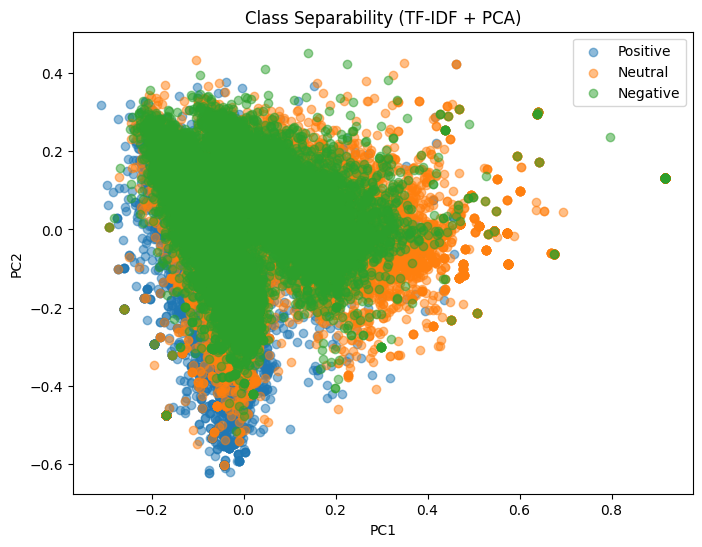

In [4]:
# Class Separability Analysis (using TF-IDF and PCA)
tf_vectorizer = TfidfVectorizer(max_features=500)
X = tf_vectorizer.fit_transform(corpus_df['Cleaned_Text'].fillna(''))

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.toarray())

plt.figure(figsize=(8,6))
for sentiment in corpus_df['Sentiment_Merged'].unique():
    idx = corpus_df['Sentiment_Merged'] == sentiment
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=sentiment, alpha=0.5)
plt.title('Class Separability (TF-IDF + PCA)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend()
plt.show()

### Prepare encodings and Train-Test Splits for Models

In [23]:
# LSTM/Transformers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(corpus_df['Sentiment_Merged'])

vocab_size = 10000
max_len = 250

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(corpus_df['Cleaned_Text'])
sequences = tokenizer.texts_to_sequences(corpus_df['Cleaned_Text'])
pad_sequences_data = pad_sequences(sequences, maxlen=max_len, truncating='post')

X_train, X_test, y_train, y_test = train_test_split(
    pad_sequences_data, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
from nltk.tokenize import word_tokenize
from gensim.models import Word2Vec

# Tokenize cleaned text
corpus_df["Tokenized_Tweet"] = corpus_df["Cleaned_Text"].apply(lambda x: word_tokenize(x))

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=corpus_df["Tokenized_Tweet"],
    vector_size=100, window=5, min_count=2, sg=1, workers=4
)

# Function to create average vector
def tweet_to_vec(tweet, model, target_size=100):
    vectors = [model.wv[word] for word in tweet if word in model.wv]
    return np.mean(vectors, axis=0) if vectors else np.zeros(target_size)

corpus_df["Tweet_Vector"] = corpus_df["Tokenized_Tweet"].apply(lambda x: tweet_to_vec(x, w2v_model))
X_word2vec = np.vstack(corpus_df["Tweet_Vector"].values)

# Split for Word2Vec data
X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_word2vec, y, test_size=0.2, random_state=42, stratify=y)

### Compute Class Weights

In [25]:
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}

### Save Processed Datasets & Processing Tools

In [26]:
import pickle
import os
save_dir = "./processed_data/"
os.makedirs(save_dir, exist_ok=True)

# Sequence data for LSTM/Transformers
np.save(f"{save_dir}X_train.npy", X_train)
np.save(f"{save_dir}X_test.npy", X_test)

# Word2Vec average vectors
np.save(f"{save_dir}X_train_word2vec.npy", X_train_w2v)
np.save(f"{save_dir}X_test_word2vec.npy", X_test_w2v)

# Labels (same across both)
np.save(f"{save_dir}y_train.npy", y_train)
np.save(f"{save_dir}y_test.npy", y_test)

# Save tokenizer and encoders
with open(f"{save_dir}tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
with open(f"{save_dir}label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)
with open(f"{save_dir}class_weights.pkl", "wb") as f:
    pickle.dump(class_weight_dict, f)

# Save cleaned dataframe
corpus_df.to_csv(f"{save_dir}Cleaned_Dataset.csv", index=False)

### Summary Report

In [27]:
import time
start_time = time.time()
# Run the preprocessing pipeline here
processing_time = time.time() - start_time

summary = f"""
PREPROCESSING SUMMARY
================================

Dataset Information:
- Total tweets: {len(corpus_df):,}
- Train set: {len(X_train):,}
- Test set: {len(X_test):,}
- Vocabulary size: {vocab_size:,}
- Processing time: {processing_time:.2f} seconds
- Processing speed: {len(corpus_df)/processing_time:.0f} tweets/second

Preprocessing Steps Completed:
✓ Emoji processing (converted to text)
✓ Non-grammatical symbol removal
✓ Named Entity Recognition # Skipped
✓ Spell correction # Skipped
✓ Abbreviation expansion
✓ Contraction expansion
✓ Punctuation cleaning
✓ Tokenization
✓ Lemmatization

Model-Ready Data Created:
✓ LSTM data: X_train_lstm.npy, X_test_lstm.npy
✓ Transformer data: X_train_transformer.npy, X_test_transformer.npy
✓ Word2Vec embeddings: w2v_embedding_matrix.npy
✓ Categorical labels: y_train.npy, y_test.npy

Ready for Models:
1. ✓ Bidirectional LSTM with learnable embeddings
2. ✓ Causal transformer with learnable embeddings
3. ✓ Causal transformer with FastText/ELMo embeddings
4. ✓ Non-causal transformer with Word2Vec embeddings
5. ✓ Non-causal transformer with learnable embeddings

Configuration saved in: tokenizer.pkl, label_encoder.pkl, class_weights.pkl
Class weights: {class_weight_dict}
"""

with open(f"{save_dir}SUMMARY.txt", "w") as f:
    f.write(summary)
print(summary)
print("PREPROCESSING COMPLETE")
print(f"All data saved to: {save_dir}")


PREPROCESSING SUMMARY

Dataset Information:
- Total tweets: 90,000
- Train set: 72,000
- Test set: 18,000
- Vocabulary size: 10,000
- Processing time: 0.00 seconds
- Processing speed: 1823610435 tweets/second

Preprocessing Steps Completed:
✓ Emoji processing (converted to text)
✓ Non-grammatical symbol removal
✓ Named Entity Recognition # Skipped
✓ Spell correction # Skipped
✓ Abbreviation expansion
✓ Contraction expansion
✓ Punctuation cleaning
✓ Tokenization
✓ Lemmatization

Model-Ready Data Created:
✓ LSTM data: X_train_lstm.npy, X_test_lstm.npy
✓ Transformer data: X_train_transformer.npy, X_test_transformer.npy
✓ Word2Vec embeddings: w2v_embedding_matrix.npy
✓ Categorical labels: y_train.npy, y_test.npy

Ready for Models:
1. ✓ Bidirectional LSTM with learnable embeddings
2. ✓ Causal transformer with learnable embeddings
3. ✓ Causal transformer with FastText/ELMo embeddings
4. ✓ Non-causal transformer with Word2Vec embeddings
5. ✓ Non-causal transformer with learnable embeddings

